# LAB 4 ANN classification - Sentinel 2 patches: Urban vs Forest


Goal of this lab is to create an ANN that correctly classify pathec of sattelite photo to 1 of 2 different classes: urban or forest.

The whole idea of this ANN can be thought as a function f(x) -> (0,1) where x is a given patch and when inserted into function f returns either 0 or 1 (forest, urban).


Lets start with creating training dataset:

In [1]:
import glob
import rasterio
import numpy as np
from rasterio.windows import from_bounds
from pyproj import Transformer


In [2]:
folder = "/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/"

band_paths = {
    b: glob.glob(f"{folder}/*_{b}_10m.jp2")[0]
    for b in ["B04", "B03", "B02", "B08"]
}

print("Found bands:", band_paths)


Found bands: {'B04': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B04_10m.jp2', 'B03': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B03_10m.jp2', 'B02': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B02_10m.jp2', 'B08': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B08_10m.jp2'}


In [3]:
def read_crop(path, bounds):
    with rasterio.open(path) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window)
    return data

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32634", always_xy=True)

PATCH_SIZE = 200     # ANN requirement
PIXEL_SIZE = 10      # Sentinel-2 10m resolution
HALF = PATCH_SIZE//2

def extract_patch(lat, lon):
    # Convert lat/lon → UTM
    x, y = transformer.transform(lon, lat)
    
    # Build bounding box in meters
    dx = HALF * PIXEL_SIZE
    dy = HALF * PIXEL_SIZE

    xmin, ymin = x - dx, y - dy
    xmax, ymax = x + dx, y + dy

    # load bands and normalize 
    scale = 1.0 / 10000.0
    b4 = read_crop(band_paths["B04"], (xmin, ymin, xmax, ymax)).astype(np.float32) * scale
    b3 = read_crop(band_paths["B03"], (xmin, ymin, xmax, ymax)).astype(np.float32) * scale
    b2 = read_crop(band_paths["B02"], (xmin, ymin, xmax, ymax)).astype(np.float32) * scale
    b8 = read_crop(band_paths["B08"], (xmin, ymin, xmax, ymax)).astype(np.float32) * scale
    patch = np.dstack((b4, b3, b2, b8))

    if patch.shape != (PATCH_SIZE, PATCH_SIZE, 4):
        return None  # skip incomplete borders

    return patch


In [4]:
urban_centers = [
    (50.06143, 19.93722),   # Rynek Główny
    (50.0645,  19.9480),    # Galeria Krakowska / Dworzec
    (50.0545,  19.9360),    # Kazimierz
    (50.0475,  19.9450),    # Podgórze
    (50.0730,  19.9400),    # Old Town north
    (50.0860,  19.9200),    # Krowodrza
    (50.0800,  19.9600),    # Grzegórzki
    (50.0700,  19.9800),    # Dąbie
    (50.0805,  19.8900),    # Bronowice
    (50.0950,  19.9300),    # Prądnik Biały
    (50.0240,  19.9500),    # Kurdwanów
    (50.0370,  19.9400),    # Łagiewniki
    (50.0700,  20.0000),    # Mogilska / Czyżyny
    (50.0780,  20.0200),    # Nowa Huta – central
    (50.0900,  20.0300),    # Nowa Huta – east
    (50.0580,  20.0100),    # Płaszów
    (50.0500,  19.9800),    # Zabłocie / industrial
    (50.0300,  19.9700),    # Ruczaj / Kampus UJ
]

forest_centers = [
    (50.0300, 20.3400),   # Puszcza Niepołomicka center
    (50.0250, 20.3600),
    (50.0150, 20.3300),
    (50.0400, 20.3500),
    (50.0350, 20.3200),
    (50.0200, 20.3100),
    (50.0100, 20.3500),
    (50.0000, 20.3400),
    (50.0450, 20.3700),
    (50.0280, 20.3800),
    (50.0180, 20.2950),
    (50.0080, 20.3050),
    (50.0380, 20.3050),
    (50.0480, 20.3300),
    (49.9980, 20.3200),
    (50.0120, 20.3650),
    (50.0220, 20.3950),
    (50.0320, 20.3150),
]


In [5]:
X = []
y = []

# URBAN = 1
for lat, lon in urban_centers:
    patch = extract_patch(lat, lon)
    if patch is not None:
        X.append(patch)
        y.append(1)

# FOREST = 0
for lat, lon in forest_centers:
    patch = extract_patch(lat, lon)
    if patch is not None:
        X.append(patch)
        y.append(0)

X = np.stack(X)
y = np.array(y).astype("float32")

print("Dataset shape:", X.shape)
print("Labels:", y)


Dataset shape: (36, 200, 200, 4)
Labels: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

Creating baseline model:

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build simple ANN
def build_simple_ann(input_shape=(200, 200, 4)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),                      # Flatten the image to a vector
        layers.Dense(64, activation="relu"),   # Hidden layer with 64 neurons
        layers.Dense(1, activation="sigmoid")  # Output layer for binary classification
    ])

    # Compile with Adam + binary crossentropy
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Create the model
ann_model = build_simple_ann()
ann_model.summary()


2025-11-13 17:03:48.201621: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-13 17:03:48.245345: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 17:03:49.278780: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1763049829.837000  199416 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763049829.845907  199416 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are install

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 160000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    10,240,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,240,129 (39.06 MB)

 Trainable params: 10,240,129 (39.06 MB)

 Non-trainable params: 0 (0.00 B)

## Training the model:

In [ ]:
history = ann_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=2
)


Epoch 1/20
3/3 - 1s - 323ms/step - accuracy: 0.3636 - loss: 14.6054 - val_accuracy: 0.3333 - val_loss: 16.4649
Epoch 2/20
3/3 - 0s - 125ms/step - accuracy: 0.6818 - loss: 5.0692 - val_accuracy: 0.6667 - val_loss: 2.2126
Epoch 3/20
3/3 - 0s - 127ms/step - accuracy: 0.3636 - loss: 5.4491 - val_accuracy: 0.3333 - val_loss: 2.3004
Epoch 4/20
3/3 - 0s - 128ms/step - accuracy: 0.6364 - loss: 1.0519 - val_accuracy: 1.0000 - val_loss: 0.0238
Epoch 5/20
3/3 - 0s - 140ms/step - accuracy: 1.0000 - loss: 0.0330 - val_accuracy: 0.3333 - val_loss: 5.1315
Epoch 6/20
3/3 - 0s - 126ms/step - accuracy: 0.8182 - loss: 1.0165 - val_accuracy: 1.0000 - val_loss: 3.6948e-04
Epoch 7/20
3/3 - 0s - 127ms/step - accuracy: 0.8636 - loss: 0.4825 - val_accuracy: 0.6667 - val_loss: 0.3555
Epoch 8/20
3/3 - 0s - 127ms/step - accuracy: 0.9545 - loss: 0.1109 - val_accuracy: 0.3333 - val_loss: 4.4980
Epoch 9/20
3/3 - 0s - 126ms/step - accuracy: 0.7727 - loss: 0.7588 - val_accuracy: 1.0000 - val_loss: 5.0618e-04
Epoch 10/

In [9]:
test_loss, test_acc = ann_model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 9.5619e-05
Test accuracy: 1.0


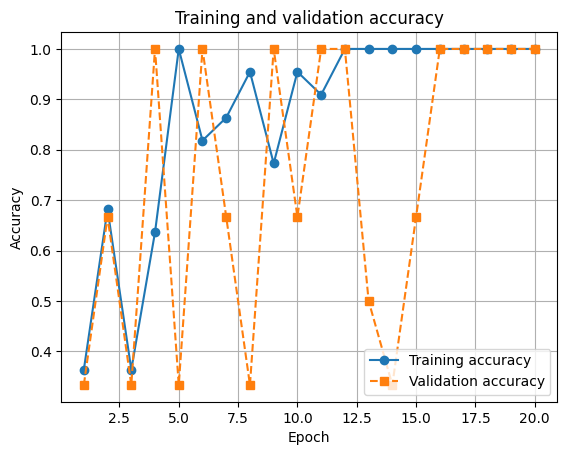

In [10]:
import matplotlib.pyplot as plt

# history.history is a dict with keys: 'loss', 'accuracy', 'val_loss', 'val_accuracy'
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, "o-", label="Training accuracy")
plt.plot(epochs, val_acc, "s--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()


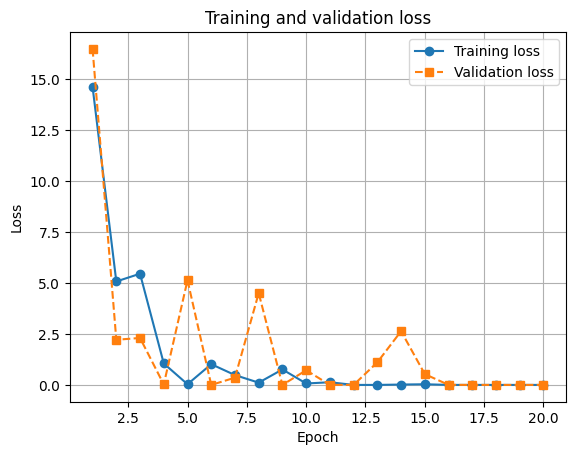

In [11]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure()
plt.plot(epochs, loss, "o-", label="Training loss")
plt.plot(epochs, val_loss, "s--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()


## Five differnet variation 
| Experiment    | Change Made                     |
| ------------- | ------------------------------- | 
| Baseline ANN  | 1 hidden layer (64 neurons)     | 
| More neurons  | Hidden layer = 128 neurons      | 
| Two layers    | 2 hidden layers (64 + 32)       | 
| With dropout  | Dropout(0.5) after hidden layer | 
| SGD optimizer | Optimizer changed → SGD         |



Running: baseline
baseline accuracy: 1.0000


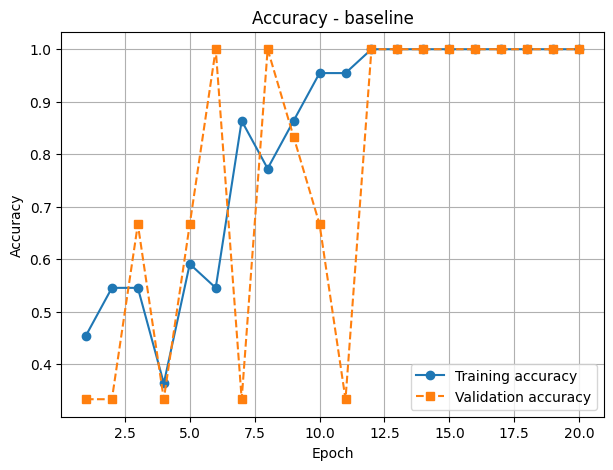

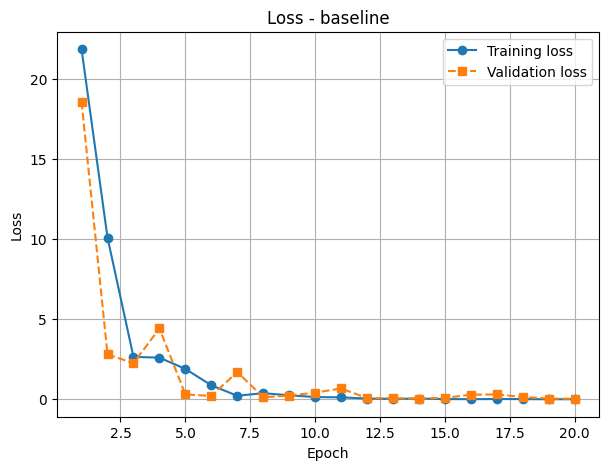


Running: more_neurons
more_neurons accuracy: 1.0000


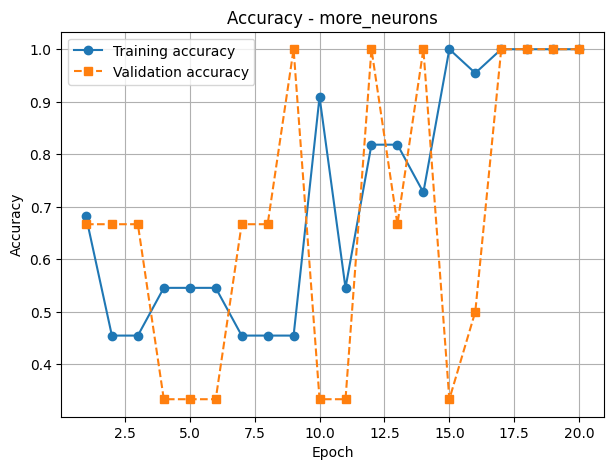

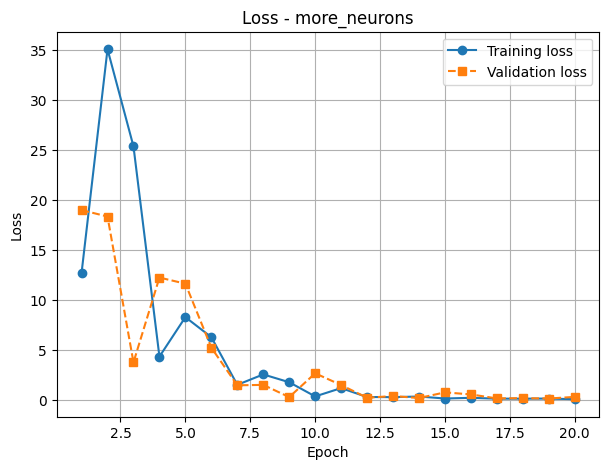


Running: two_layers
two_layers accuracy: 1.0000


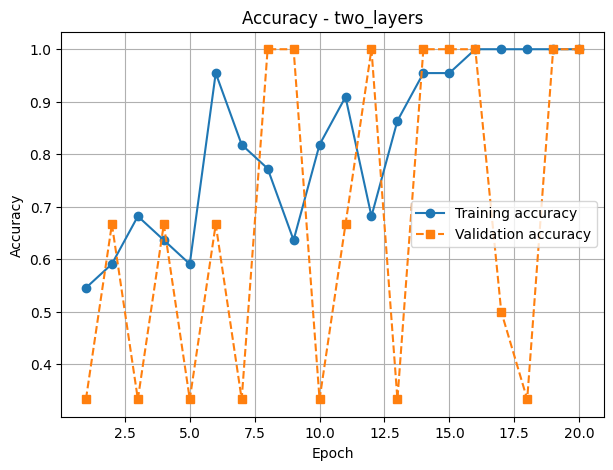

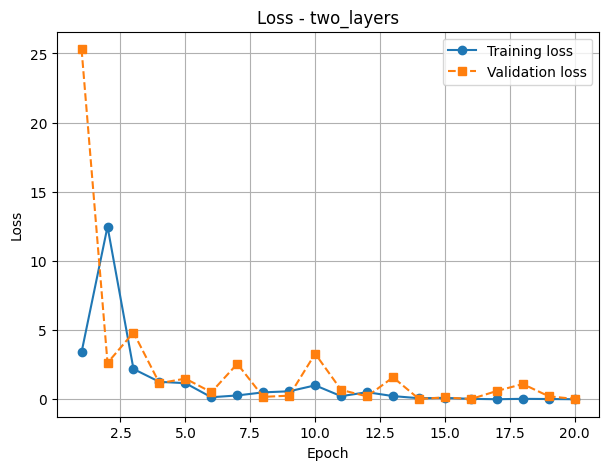


Running: with_dropout
with_dropout accuracy: 1.0000


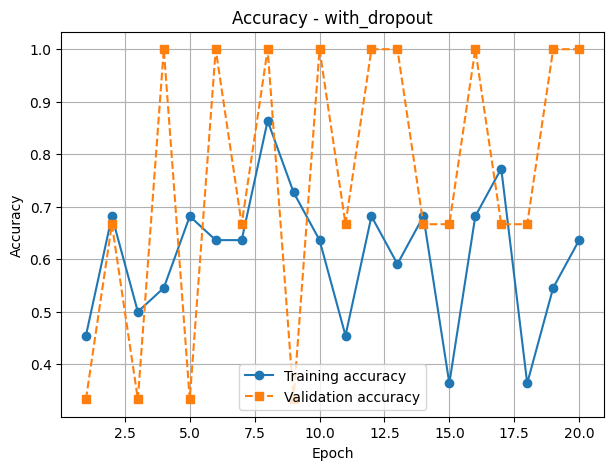

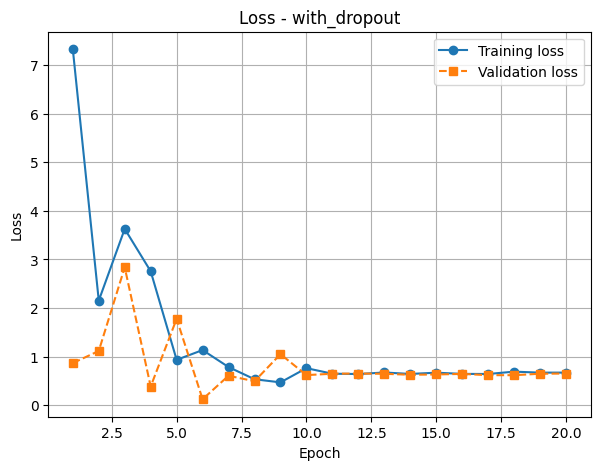


Running: sgd_optimizer
sgd_optimizer accuracy: 0.8750


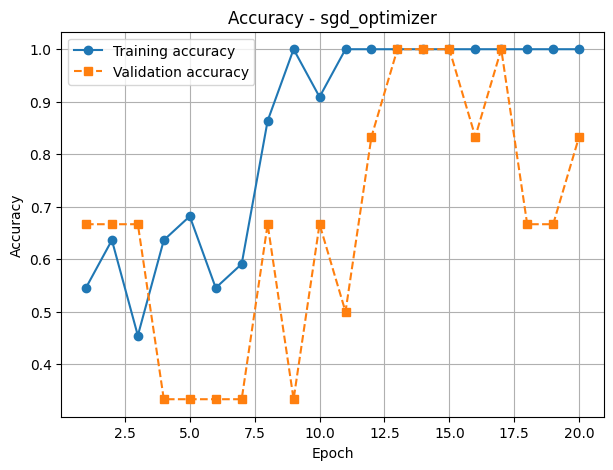

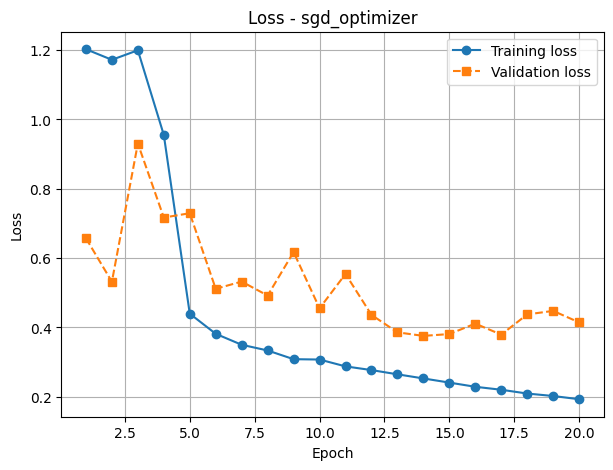

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

def make_ann(hidden_units=64, second_layer=False, dropout=False):
    model = models.Sequential([
        layers.Input(shape=(200,200,4)),
        layers.Flatten()
    ])
    
    model.add(layers.Dense(hidden_units, activation="relu"))
    
    if second_layer:
        model.add(layers.Dense(32, activation="relu"))
    
    if dropout:
        model.add(layers.Dropout(0.5))

    model.add(layers.Dense(1, activation="sigmoid"))
    
    return model


experiments = {
    "baseline": make_ann(hidden_units=64),
    "more_neurons": make_ann(hidden_units=128),
    "two_layers": make_ann(hidden_units=64, second_layer=True),
    "with_dropout": make_ann(hidden_units=64, dropout=True),
    "sgd_optimizer": make_ann(hidden_units=64)
}

results = {}

for name, model in experiments.items():
    print("\nRunning:", name)

    # Optimizer choice
    if name == "sgd_optimizer":
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )
    else:
        model.compile(
            optimizer="adam",
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=8,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = acc
    print(f"{name} accuracy: {acc:.4f}")

    #plots
    epochs = range(1, len(history.history["loss"]) + 1)

    # Accuracy plot
    plt.figure(figsize=(7,5))
    plt.plot(epochs, history.history["accuracy"], "o-", label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], "s--", label="Validation accuracy")
    plt.title(f"Accuracy - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Loss plot
    plt.figure(figsize=(7,5))
    plt.plot(epochs, history.history["loss"], "o-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "s--", label="Validation loss")
    plt.title(f"Loss - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()
